# 1. Generar conjunto de datos sintéticos

Generar un conjunto de datos sintético con 150 observaciones y 50 variables (X₁, X₂, …, X₅₀). Las variables deben tener correlaciones no nulas entre sí. Para lograrlo,
utilizar una matriz de correlaciones (provista en el EVA) y generar los datos con una
distribución normal multivariada.

Cargar la matriz de correlación

In [41]:
import numpy as np
import pandas as pd

cov_matrix = pd.read_csv('mat_cov.csv').values

In [42]:
np.random.seed(42)

n_samples = 150
n_features = 50

mean = np.zeros(n_features)

# Generar datos sintéticos con Distribución Normal Multivariada
X = np.random.multivariate_normal(mean, cov_matrix, size=n_samples)

# Convertir a DataFrame
X_df = pd.DataFrame(X, columns=[f'X{i+1}' for i in range(n_features)])

In [43]:
X_df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50
0,0.186308,-0.820221,0.422954,0.190821,-1.320801,-0.454796,0.804937,-1.703741,-0.353018,0.103973,...,-0.361749,0.678168,0.289063,-0.463401,-0.146830,-0.146265,1.055668,-0.172807,-0.155737,1.221115
1,0.918081,0.025233,-0.178135,-0.653559,-0.742937,-0.724692,0.592756,0.361891,0.816047,0.347074,...,0.400291,0.046623,0.095804,-0.347168,0.189116,1.255416,-0.712092,-0.358778,0.000080,0.678081
2,-0.943178,-0.355982,-1.254916,0.594678,0.496199,-0.462866,-0.215763,1.047683,-0.133262,0.646307,...,-0.653090,1.054205,0.980147,-0.120957,-0.402486,-1.335639,-1.279100,0.495933,0.321842,-0.505359
3,0.187396,-0.260711,-0.647634,-0.088311,-0.404784,-0.364406,0.354536,0.489012,-0.413760,-1.125269,...,-0.449818,1.208946,-1.079749,-0.031084,1.052038,0.965266,-0.297255,0.414274,-0.138381,0.552097
4,-0.165754,-0.010144,0.395370,0.103226,0.121329,0.070942,1.224411,-0.745223,-0.083532,0.851168,...,-0.494927,1.737413,-0.203094,-1.131112,1.543805,0.142476,0.773700,0.760420,-0.345862,-0.146012


# 2. Definir una variable objetivo Y


Definir una variable objetivo Y como combinación lineal de las 50 variables, donde
solo 5 serán informativas (tendrán coeficientes no nulos). Agregar un pequeño ruido
aleatorio gaussiano con media cero y poca varianza (por ejemplo, 0.25).

In [44]:
np.random.seed(42)
n_informativas = 5
n_variables = X.shape[1]

# Índices de las variables informativas
informativas_idx = np.random.choice(n_variables, n_informativas, replace=False)

coeficientes = np.zeros(n_variables)
coeficientes[informativas_idx] = np.random.uniform(1, 5, size=n_informativas)

# Generar Y como combinación lineal + ruido gaussiano
ruido = np.random.normal(loc=0, scale=0.25, size=X.shape[0])
Y = X @ coeficientes + ruido

# 3. Separar los datos

* Conjunto de entrenamiento: 100 observaciones 
* Conjunto de test: 50 observaciones 

In [45]:
X_train = X[:100]
y_train = Y[:100]

X_test = X[100:]
y_test = Y[100:]

# 4. Entrenamientro de modelos

Entrenar tres modelos distintos utilizando el conjunto de entrenamiento: Regresión
lineal simple, Regresión Ridge y Regresión Bayesiana. Graficar los coeficientes
(pesos) estimados para cada una de las 50 variables.
Comparar los resultados y comentar respecto a las variables que sabemos que
contienen información. Elegir uno de los modelos para continuar, justificando la
elección

In [46]:
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge
import matplotlib.pyplot as plt

## Regresión Lineal

In [47]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
coef_lr = modelo_lr.coef_

## Regresión Ridge

In [48]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)
coef_ridge = modelo_ridge.coef_

## Regresión Bayesiana

In [49]:
modelo_bayesiano = BayesianRidge()
modelo_bayesiano.fit(X_train, y_train)
coef_bayes = modelo_bayesiano.coef_

## Graficar y comparar

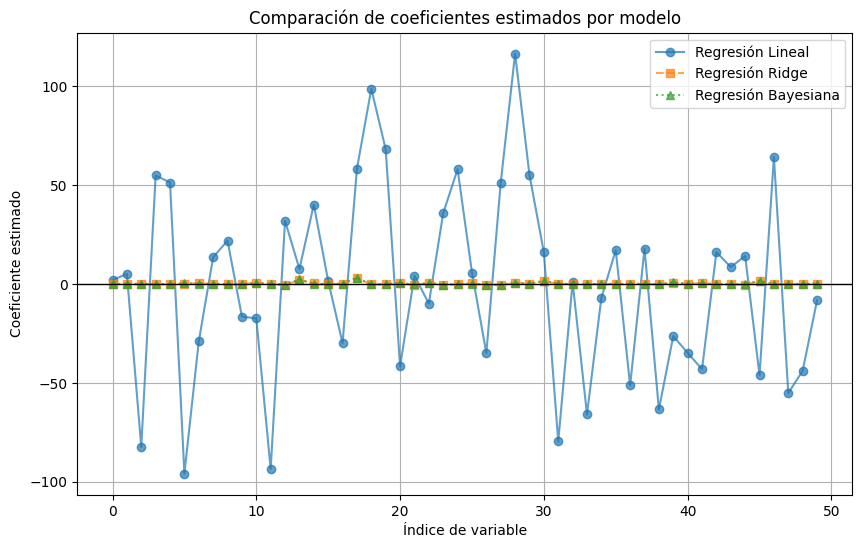

In [50]:
# Graficar los coeficientes
plt.figure(figsize=(10, 6))
indices = np.arange(len(coef_lr))

plt.plot(indices, coef_lr, label="Regresión Lineal", linestyle='-', marker='o', alpha=0.7)
plt.plot(indices, coef_ridge, label="Regresión Ridge", linestyle='--', marker='s', alpha=0.7)
plt.plot(indices, coef_bayes, label="Regresión Bayesiana", linestyle=':', marker='^', alpha=0.7)

plt.xlabel("Índice de variable")
plt.ylabel("Coeficiente estimado")
plt.title("Comparación de coeficientes estimados por modelo")
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# Sombrear las variables informativas y señalarlas
for idx in informativas_idx:
    plt.text(idx, coef_lr[idx], f'X{idx + 1}', color='green', ha='center', va='bottom', fontsize=8)

# Mostrar coeficientes reales y estimados en las variables informativas
print("Coeficientes reales y estimados en las variables informativas:\n")
for i in informativas_idx:
    print(f"Variable X{i + 1:02d}:")
    print(f"   Verdadero coeficiente: {coeficientes[i]:.3f}")
    print(f"   Estimado (Lineal):     {coef_lr[i]:.3f}")
    print(f"   Estimado (Ridge):      {coef_ridge[i]:.3f}")
    print(f"   Estimado (Bayesiano):  {coef_bayes[i]:.3f}")
    print("-" * 50)

Coeficientes reales y estimados en las variables informativas:

Variable X14:
   Verdadero coeficiente: 2.542
   Estimado (Lineal):     7.616
   Estimado (Ridge):      2.031
   Estimado (Bayesiano):  2.368
--------------------------------------------------
Variable X40:
   Verdadero coeficiente: 1.064
   Estimado (Lineal):     -26.279
   Estimado (Ridge):      0.736
   Estimado (Bayesiano):  0.866
--------------------------------------------------
Variable X31:
   Verdadero coeficiente: 1.924
   Estimado (Lineal):     15.975
   Estimado (Ridge):      1.319
   Estimado (Bayesiano):  1.702
--------------------------------------------------
Variable X46:
   Verdadero coeficiente: 1.964
   Estimado (Lineal):     -46.119
   Estimado (Ridge):      1.428
   Estimado (Bayesiano):  1.662
--------------------------------------------------
Variable X18:
   Verdadero coeficiente: 3.733
   Estimado (Lineal):     58.266
   Estimado (Ridge):      2.904
   Estimado (Bayesiano):  3.190
----------------

## Modelo elegido

Visualmente, los coeficientes no informativos:
- En el modelo lineal parece haber mucho ruido en los coeficientes.
- En Ridge y Bayesiana, se acercan mucho a 0.

Solo 5 variables son realmente informativas, es decir, sus coeficientes son diferentes de 0.
Las otras 45 variables son ruido, por lo que deberían tener valores cercanos a 0.
Teniendo esto en cuenta, el modelo lineal quedaría descartado.

El modelo Ridge depende de un solo parametro de ajuste, que influye en la intesidad de penalización. Con validación curzada se lo puede optimizar hasta encontrar el punto óptimo entre sesgo y varianza.
Por otro lado, en el modelo Bayesiano hay múltiples parámetros de precisión, por lo que requiere de algún método iterativo para estimar los coeficientes. Esto hace que el proceso sea más complejo y computacionalmente costoso.

A partir de los números:
La regresión lineal produce coeficientes inestables y valores extremadamente alejados de los verdaderos.
En cambio, tanto Ridge como la Bayesiana logran estimaciones estables y razonablemente cercanas a los valores reales.

Se concluye que la mejor opción es Ridge.

# 5. Análisis de componentes principales al conjunto de entrenamiento

Se procede a trabajar con PCA estandarizado sobre el conjunto de entrenamiento, para ello se estandarizan nuestros datos ya que PCA es sensible a la escala de los datos (recae en distancias euclidianas).

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [53]:
# Se estandarizan los valores de las variables observadas para el PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


La idea es proyectar sobre las dos componentes principales.

In [54]:
# PCA sobre las dos principales componentes 
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_train_scaled)
print(X_pca.shape)

(100, 2)


Luego graficamos las observaciones proyectadas:

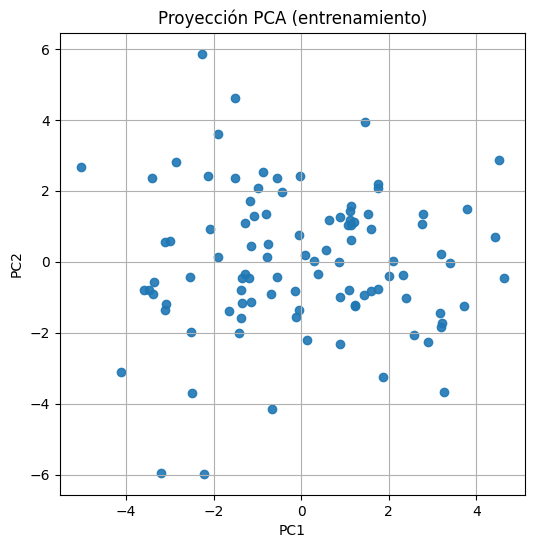

In [55]:
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.9)
plt.title("Proyección PCA (entrenamiento)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# 6. Generación de datos de una distribución desplazada

Particionamos el conjunto de testing en dos subconjuntos: uno con la distribucion original y otro desplazado.

In [56]:
X_test_A = X_test[:25].copy()
X_test_B = X_test[25:].copy()

Luego generamos un desplazamiento aleatoreo a cada observacion (fila)

In [57]:
shift = np.random.uniform(-10, 10, size=50)
X_test_A_shifted = X_test_A + shift

# 7. Predicción en ambos conjuntos de testing

Usar el modelo elegido en la parte 2 para predecir sobre ambos conjuntos (A
modificado y B). Calcular el error de predicción en cada observación. Comentar los
resultados.

In [58]:
# i. Predecir en ambos subconjuntos
y_pred_A = modelo_ridge.predict(X_test_A_shifted)
y_pred_B = modelo_ridge.predict(X_test_B)

# ii. Calcular errores por observación
errores_A = (y_test[:25] - y_pred_A) ** 2  # error cuadrático observación a observación
errores_B = (y_test[25:] - y_pred_B) ** 2

# iii. Error global promedio para cada subconjunto
mse_A = np.mean(errores_A)
mse_B = np.mean(errores_B)

print("MSE conjunto A (modificado) =", mse_A)
print("MSE conjunto B (original)   =", mse_B)

MSE conjunto A (modificado) = 563.0743053640075
MSE conjunto B (original)   = 0.18849827999626462


### Interpretación de Resultados:

El conjunto B proviene de la misma distribución que los datos de entrenamiento. El modelo debería predecir bien, o sea tener un error pequeño.

El conjunto A fue desplazado sumándole una constante random a todas las variables.
Esto cambia la distribución de entrada, entonces el modelo ya no reconoce estos datos como similares a los entrenados. Por lo tanto, el error debería ser más grande.

Finalmente, Se concluye que el modelo aprende una relación válida dentro de la distribución de entrenamiento, pero cuando los datos cambian ligeramente (distribución desplazada), el desempeño del modelo empeora drásticamente (el MSE obtenido es más de 3000 veces mayor que el del conjunto B, con una entrada que varía a lo sumo en 10 unidades por variable con respecto al conjunto original). El modelo es altamente inestable y sensible ante pequeños cambios en la distribución de entrada.


# 8. PCA a los conjuntos de test A y B

Proyectar los conjuntos A y B en el espacio de las componentes principales
obtenidas en la parte 3 y graficar las proyecciones (PC1 vs PC2), coloreando los
puntos según el error de predicción. Comentar los resultados.

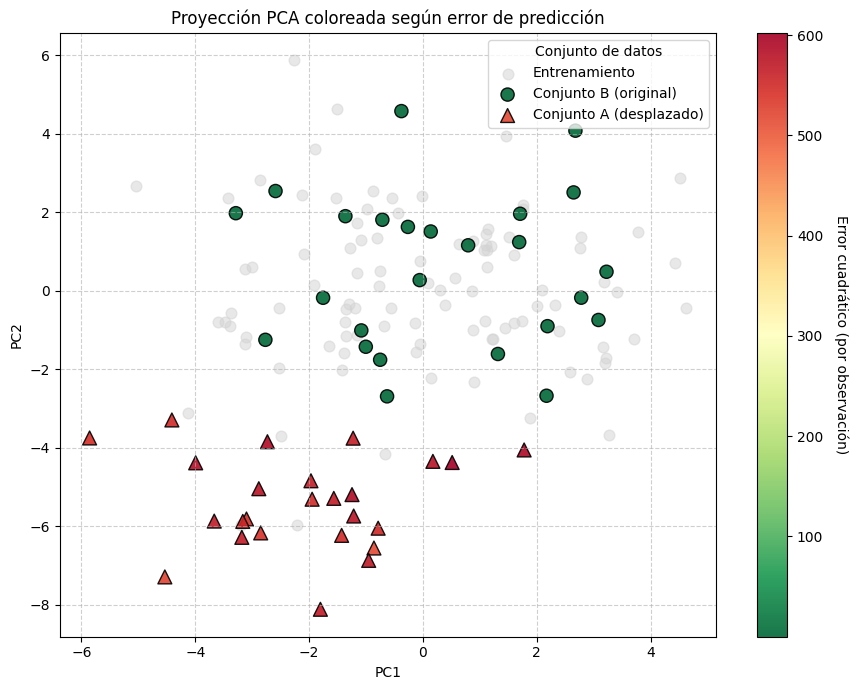

In [60]:
# Predicciones del modelo en cada conjunto
y_pred_A = modelo_ridge.predict(X_test_A_shifted)
y_pred_B = modelo_ridge.predict(X_test_B)

# Error cuadratico
errores_A = (y_test[:25] - y_pred_A) ** 2
errores_B = (y_test[25:] - y_pred_B) ** 2

# i. Estandarizar ambos conjuntos usando el scaler del entrenamiento
X_A_scaled = scaler.transform(X_test_A_shifted)
X_B_scaled = scaler.transform(X_test_B)

# ii. Proyectar en las dos primeras componentes principales
X_A_pca = pca.transform(X_A_scaled)
X_B_pca = pca.transform(X_B_scaled)
X_train_pca = pca.transform(X_train_scaled)

# iii. Definir rango de color común para los errores
vmin = min(errores_A.min(), errores_B.min())
vmax = max(errores_A.max(), errores_B.max())

# iv. Graficar todo en una misma figura
plt.figure(figsize=(9, 7))

# Nube gris: conjunto de entrenamiento
plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    color='lightgray', alpha=0.5, s=60,
    label="Entrenamiento"
)

# Conjunto B (original)
plt.scatter(
    X_B_pca[:, 0], X_B_pca[:, 1],
    c=errores_B, cmap="RdYlGn_r",
    vmin=vmin, vmax=vmax,
    label="Conjunto B (original)",
    s=90, marker="o", edgecolor='k', alpha=0.9
)

# Conjunto A (desplazado)
plt.scatter(
    X_A_pca[:, 0], X_A_pca[:, 1],
    c=errores_A, cmap="RdYlGn_r",
    vmin=vmin, vmax=vmax,
    label="Conjunto A (desplazado)",
    s=100, marker="^", edgecolor='k', alpha=0.9
)

# Barra de color compartida
cbar = plt.colorbar()
cbar.set_label("Error cuadrático (por observación)", rotation=270, labelpad=18)

# Configuración del gráfico
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA coloreada según error de predicción")
plt.legend(title="Conjunto de datos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Comentarios
Los puntos del conjunto B se concentran en una región similar a la nube de entrenamiento.
Esto confirma que el modelo mantiene un buen desempeño cuando los datos provienen de la misma distribución que la usada para el entrenamiento, reproduciendo correctamente la relación entre las variables informativas y la variable objetivo.
El modelo opera dentro de su dominio de validez.

## Observaciones sobre el conjunto A (modificado)
Por otro lado, los puntos del conjunto A muestran una mayor dispersión, estando fuera de la nube entrenamiento. Además, muestran errores significativamente mayores.
Esto es coherente con el desplazamiento artificial aplicado a las variables de entrada, ya que al modificar la entrada de cada atributo, el modelo Ridge ya no logra generalizar correctamente.

## Conclusiones
Gracias a la proyección PCA, se observa gráficamente la relación directa entre la ubicación de los datos de entrada y el rendimiento del modelo. El modelo generaliza bien dentro de su distribución de entrenamiento, pero su rendimiento se deteriora drásticamente cuando los datos de entrada sufren un desplazamiento de sus valores respecto a la distribución original.

# Pregunta Final 

Si no conociera las constantes que se le sumaron a las variables del conjunto A, ¿qué estrategia elegiría para mejorar las predicciones en ese conjunto?


La estrategia clave sería la recalibración del conjunto de datos A mediante la reestandarización. La brusca caída en el rendimiento (alto MSE) en el conjunto A, junto con la evidencia gráfica del PCA, confirma la presencia de un desplazamiento de los datos de entrada respecto a la distribución original.
La solución recae en mitigar el efecto de la constante de desplazamiento desconocida. Esto se logra ajustando el centro de los datos del conjunto A al centro esperado por el modelo entrenado.
Para esto, Se reestandariza el conjunto A de forma independiente, utilizando su propia media ($\mu_A$) y desviación estándar ($\sigma_A$):
$$X'_{\text{A}} = \frac{X_{\text{A}} - \mu_{\text{A}}}{\sigma_{\text{A}}}$$

La justificación recae en que al reestandarizar, se compensa el desplazamiento en el centro (media) y la posible alteración en la escala, devolviendo las variables del conjunto A a un dominio similar al del entrenamiento. Así, el modelo Ridge, que ya conoce cómo se relacionan las variables, puede volver a usar lo que aprendió de forma efectiva.